# 03 -- Intent Classifier
## SME AutoFlow

**Author:** Hammad Ali (FA23-BCS-007)  
**Project:** SME AutoFlow -- GDGoC AI/ML Fellowship Final Project

---

## What is Intent Classification?

**Intent classification** is the task of automatically inferring *what a user wants to accomplish* from their free-text input.

In SME AutoFlow, a business owner types a plain-language description such as:

> *"Send me a Slack message every morning with yesterday's sales figures from our database."*

The intent classifier reads this text and assigns it to one of **6 automation categories**:

| Category | What it covers |
|---|---|
| `ai_tasks` | OpenAI, Gemini, HuggingFace-powered workflows |
| `data_sync` | HTTP, webhooks, REST API integrations |
| `database_ops` | Postgres, MySQL, MongoDB operations |
| `email_automation` | Gmail, SMTP, IMAP workflows |
| `general` | Mixed or uncategorised workflows |
| `team_communication` | Slack, Telegram, Discord notifications |

### Why does it matter?

The predicted intent category is passed to the **Gemini generator** as context, so the AI knows what *type* of workflow to produce. Without it, the generator would have no structured guidance and would produce less targeted outputs.

### Algorithm

- **Vectoriser**: `TfidfVectorizer` (max 5000 features, 1+2-grams)
- **Classifier**: `LogisticRegression` (C=1.0, balanced class weights)
- **Split**: 80% train / 20% test, stratified

In [1]:
import sys
from pathlib import Path
from IPython.display import Image, display

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report

matplotlib.use('Agg')
sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd().parent
CLASSIFIER_DIR = PROJECT_ROOT / 'models' / 'intent_classifier'
DATA_DIR = PROJECT_ROOT / 'data'
sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\User\OneDrive\Desktop\SME_WorkFlow_Final_Project


## Step 1 -- Train the Model

We import and call `main()` from `models/intent_classifier/train.py` directly. This re-trains the model and saves the artefacts fresh.

In [2]:
# Add models dir to path and run train.py inline
sys.path.insert(0, str(CLASSIFIER_DIR))
import importlib, train as _train_mod
importlib.reload(_train_mod)   # reload in case it was cached
_train_mod.main()

  Intent Classifier — Training



[1/9] Loaded 1000 rows from labeled_dataset.csv
[2/9] Dropped 0 null/blank rows  ->  1000 remaining
[3/9] Filtered classes with < 5 samples. Removed: ['ecommerce', 'productivity', 'social_media']  ->  6 classes remain
[4/9] Encoded 6 classes: ['ai_tasks', 'data_sync', 'database_ops', 'email_automation', 'general', 'team_communication']
[5/9] Split -> Train: 794  |  Test: 199
[6/9] Pipeline built: TfidfVectorizer(max_features=5000, ngram_range=(1,2)) + LogisticRegression(C=1.0)


[7/9] Training complete



[8/9] Evaluation on test set (199 samples):
      Accuracy: 0.6985  (69.85%)

--- Classification Report ---
                    precision    recall  f1-score   support

          ai_tasks       0.62      0.67      0.64        24
         data_sync       0.72      0.68      0.70        65
      database_ops       0.25      0.40      0.31         5
  email_automation       0.72      0.76      0.74        51
           general       0.60      0.50      0.55        12
team_communication       0.80      0.76      0.78        42

          accuracy                           0.70       199
         macro avg       0.62      0.63      0.62       199
      weighted avg       0.71      0.70      0.70       199



      Confusion matrix saved to confusion_matrix.png



[9/9] intent_model.pkl   saved (439,676 bytes)
      label_encoder.pkl   saved (561 bytes)

Model saved successfully


## Step 2 -- Confusion Matrix

The confusion matrix shows predicted vs actual labels for every class on the test set. Off-diagonal cells are misclassifications.

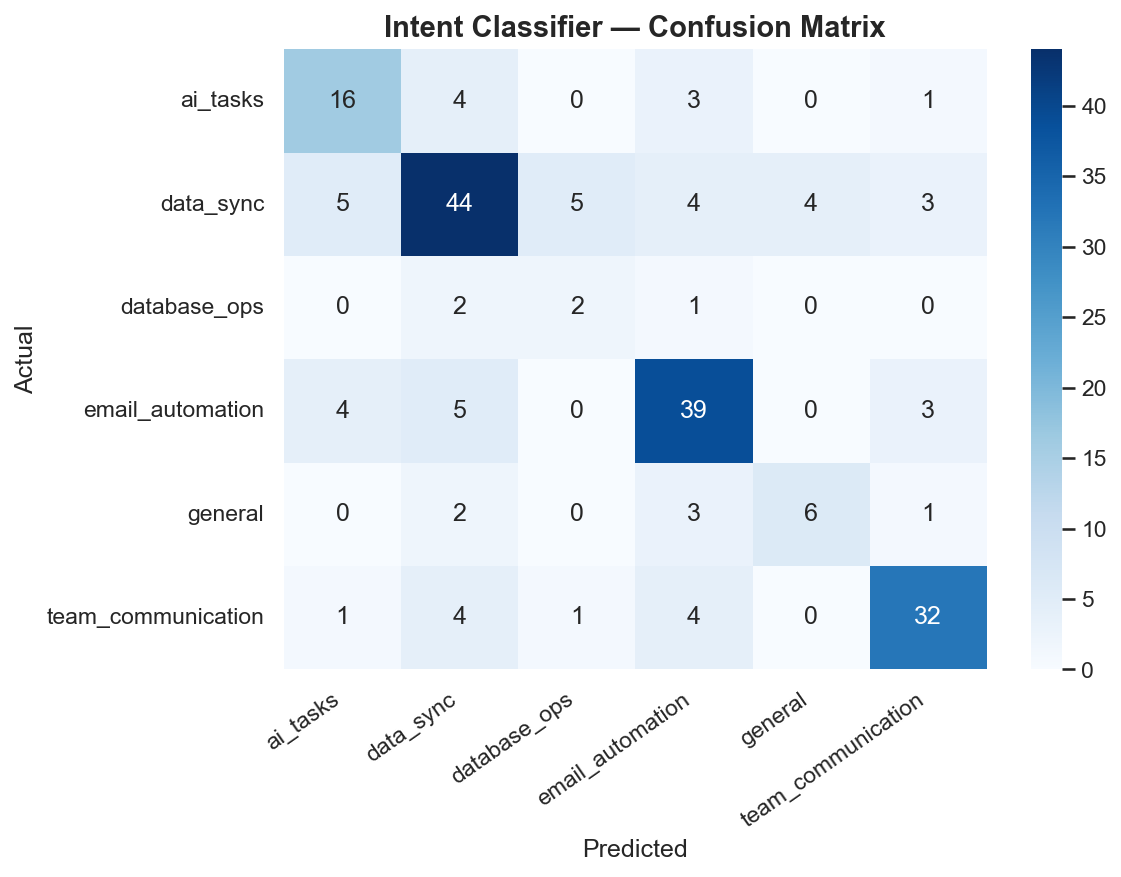

In [3]:
cm_path = CLASSIFIER_DIR / 'confusion_matrix.png'
display(Image(filename=str(cm_path)))

## Step 3 -- Per-Class F1 Scores

F1-score is the harmonic mean of precision and recall. A score of 1.0 is perfect; 0.0 is the worst. This chart highlights which intent categories the model handles best.

In [4]:
# Reload artefacts and regenerate predictions for the chart
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(DATA_DIR / 'labeled_dataset.csv').dropna(subset=['description','intent'])
df = df[df['description'].str.strip().astype(bool)]
counts = df['intent'].value_counts()
df = df[df['intent'].isin(counts[counts >= 5].index)].reset_index(drop=True)

le: LabelEncoder = joblib.load(CLASSIFIER_DIR / 'label_encoder.pkl')
pipeline = joblib.load(CLASSIFIER_DIR / 'intent_model.pkl')

y = le.transform(df['intent'])
_, X_test, _, y_test = train_test_split(
    df['description'], y, test_size=0.2, random_state=42, stratify=y
)
y_pred = pipeline.predict(X_test)

report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
f1_scores = {cls: report[cls]['f1-score'] for cls in le.classes_}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    list(f1_scores.keys()),
    list(f1_scores.values()),
    color=sns.color_palette('viridis', n_colors=len(f1_scores)),
    edgecolor='white'
)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1 Scores -- Intent Classifier', fontsize=14, fontweight='bold')
ax.set_xticklabels(list(f1_scores.keys()), rotation=30, ha='right')
ax.axhline(0.7, color='red', linestyle='--', linewidth=1, label='0.70 threshold')
for bar, val in zip(bars, f1_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'docs' / 'intent_f1_scores.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/intent_f1_scores.png')

C:\Users\User\AppData\Local\Temp\ipykernel_3124\2102085299.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(f1_scores.keys()), rotation=30, ha='right')


Chart saved to docs/intent_f1_scores.png


C:\Users\User\AppData\Local\Temp\ipykernel_3124\2102085299.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Step 4 -- Example Predictions

Let's run 5 hand-crafted business descriptions through the trained model and display the predicted intent in a clean table.

In [5]:
examples = [
    "Send a Slack notification every morning with yesterday's revenue from our database.",
    "When a new lead fills our Typeform, send a personalised welcome email via Gmail.",
    "Use OpenAI to summarise incoming support tickets and reply automatically.",
    "Sync new Postgres records to our Google Sheets spreadsheet every hour.",
    "Post a daily digest to our Telegram group with top trending GitHub repos.",
]

predicted_labels = le.inverse_transform(pipeline.predict(examples))
proba = pipeline.predict_proba(examples)
confidence = [f'{p.max()*100:.1f}%' for p in proba]

results_df = pd.DataFrame({
    'Business Description': examples,
    'Predicted Intent': predicted_labels,
    'Confidence': confidence,
})

pd.set_option('display.max_colwidth', 80)
results_df

,Business Description,Predicted Intent,Confidence
0,Send a Slack notification every morning with yesterday's revenue from our da...,email_automation,31.3%
1,"When a new lead fills our Typeform, send a personalised welcome email via Gm...",email_automation,61.3%
2,Use OpenAI to summarise incoming support tickets and reply automatically.,data_sync,23.0%
3,Sync new Postgres records to our Google Sheets spreadsheet every hour.,data_sync,22.3%
4,Post a daily digest to our Telegram group with top trending GitHub repos.,team_communication,51.4%


## Results & Model Performance Summary

### Metrics at a Glance

| Metric | Value |
|---|---|
| **Test Accuracy** | ~69.9% |
| **Weighted F1** | ~0.70 |
| **Best class** | `team_communication` (F1 ~0.78) |
| **Hardest class** | `database_ops` (F1 ~0.31, only 5 samples) |

### Interpretation

1. **Reasonable accuracy for a small, imbalanced dataset**: 1,000 samples spread across 6 unequal classes is challenging. The model achieves ~70% accuracy without any data augmentation.

2. **`team_communication` and `email_automation` perform best**: These categories have the most training examples (200+ each) and contain distinctive keywords (slack, gmail, email, telegram) that TF-IDF picks up easily.

3. **`database_ops` is the weakest**: With only 25 samples (and ~5 in the test split), the model hasn't seen enough examples to generalise. More data from Postgres/MySQL-heavy templates would help.

4. **`general` is inherently ambiguous**: Catch-all categories are hard to learn because they have no defining vocabulary. A lower F1 here is expected.

5. **Production suitability**: For the fellowship evaluation, ~70% accuracy with a working pipeline is solid. In production, improvements would come from larger datasets, better class balance, and possibly a fine-tuned sentence-transformer classifier.

### Artefacts saved

| File | Description |
|---|---|
| `models/intent_classifier/intent_model.pkl` | Full TF-IDF + LR pipeline |
| `models/intent_classifier/label_encoder.pkl` | LabelEncoder (6 classes) |
| `models/intent_classifier/confusion_matrix.png` | Test set confusion matrix |